In [2]:
import pandas as pd
import numpy as np

## Plot percent returns vs log returns for a range of values

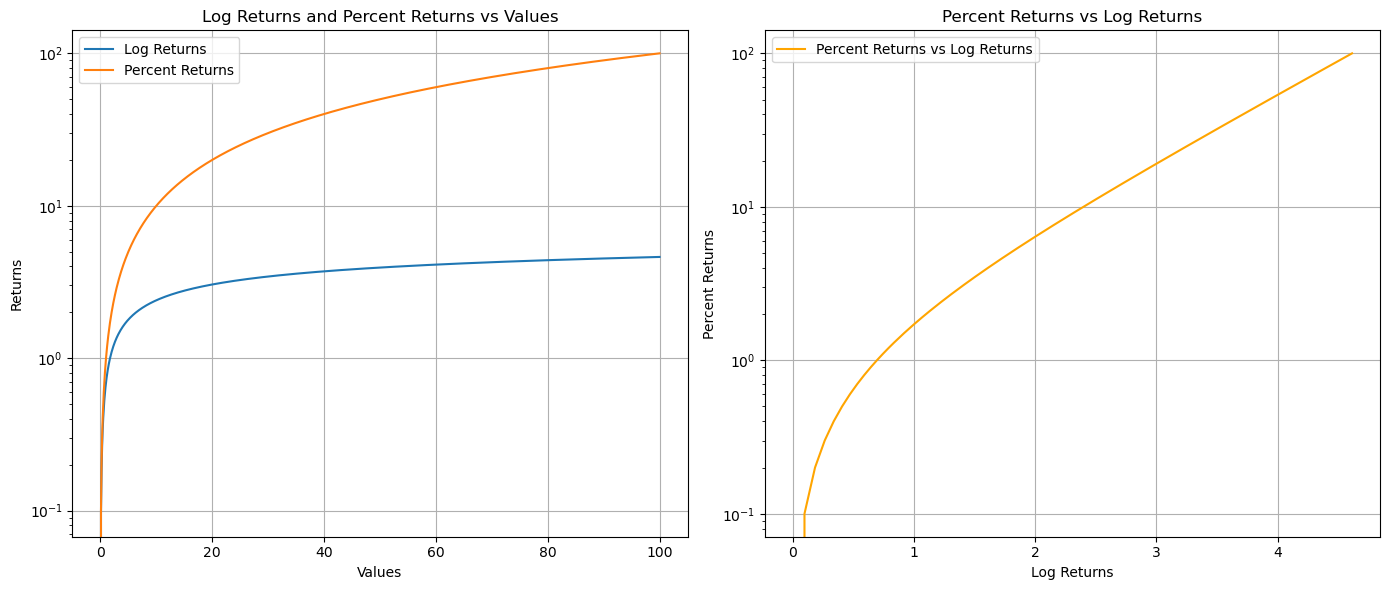

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of values
values = np.linspace(0, 100, 1000)

# Calculate log returns
log_returns = np.log(values + 1)  # Adding 1 to avoid log(0)

# Calculate percent returns
percent_returns = np.exp(log_returns) - 1


# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot percent returns vs values
ax1.plot(values, log_returns, label='Log Returns')
ax1.plot(values, percent_returns, label='Percent Returns')
ax1.set_yscale('log')
ax1.set_xlabel('Values')
ax1.set_ylabel('Returns')
ax1.set_title('Log Returns and Percent Returns vs Values')
ax1.legend()
ax1.grid(True)

# Plot percent returns vs log returns
ax2.plot(log_returns, percent_returns, label='Percent Returns vs Log Returns', color='orange')
ax2.set_yscale('log')
ax2.set_xlabel('Log Returns')
ax2.set_ylabel('Percent Returns')
ax2.set_title('Percent Returns vs Log Returns')
ax2.legend()
ax2.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

## Vectorized Backtesting

In [5]:
bull =      [0,0,0,1,1,1,1,0,0,0,0,0,1,1,1,0,0,1,1,1]
bull_exit = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

bear =      [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
bear_exit = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
close = np.random.uniform(2000, 3000, len(bull)).astype(int)

In [6]:

short_long = [1,-1]

# Define transaction costs and slippage
transaction_cost = 0.001  # 0.1% transaction cost per trade
slippage = 0.001  # 0.1% slippage per trade

data = pd.DataFrame({'close': close , 'bull': bull, 'bull_exit': bull_exit, 'bear':bear, 'bear_exit':bear_exit})

lclose = data['close'].apply(np.log)
data['position'] = ((1 in short_long) * (data['bull'] &~ data['bull_exit'])) - ((-1 in short_long) * (data['bear'] &~ data['bear_exit']))
positions_shifted = data['position'].shift().fillna(0).astype(int)
# data['positions_shifted'] = positions_shifted
data['trade'] = data['position'].diff().fillna(0).astype(int)
data.at[data.index[-1],'trade'] = -data.iloc[-1]['position']
data['strategy_returns'] = positions_shifted * (lclose.diff().fillna(0))
# trade_abs = data['trade_abs'] = data['trade'].abs()
number_of_trades = data['trade'].abs().sum()
data['strategy_returns'] -= data['trade'].abs() * (transaction_cost + slippage)
# data['cum_trade_returns'] = (-lclose * data['trade'] - (data['trade'].abs() * (transaction_cost + slippage))).cumsum() *(data['trade'] != 0)

data['entry_point'] = ((data['position'] != 0) & (data['position'] == np.sign(data['trade']))).astype(int)
data['exit_point'] = ((positions_shifted != 0) & (positions_shifted == np.sign(-data['trade']))).astype(int)

data['cumulative_returns'] = data['strategy_returns'].cumsum()
data['cum_trade_returns'] = data['cumulative_returns'] * data['exit_point']
# data.loc[(data['trade'] == 0), 'cum_trade_returns'] = 0
data['cum_trade_returns'].replace(0, pd.NA, inplace=True)
data['cum_trade_returns'] = data['cum_trade_returns'].fillna(method='ffill').fillna(0)#.diff().fillna(0)
# data['trade_returns']  = data['strategy_returns'] * (positions_shifted == -np.sign(data['trade']))
# data['cum_trade_returns'] = data['trade_returns'].cumsum()

data

/tmp/ipykernel_558168/3898482698.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['cum_trade_returns'].replace(0, pd.NA, inplace=True)
/tmp/ipykernel_558168/3898482698.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['cum_trade_returns'] = data['cum_trade_returns'].fillna(method='ffill').fillna(0)#.diff().fillna(0)
/tmp/ipykernel_558168/3898482698.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .

,close,bull,bull_exit,bear,bear_exit,position,trade,strategy_returns,entry_point,exit_point,cumulative_returns,cum_trade_returns
0,2447,0,0,0,0,0,0,0.000000,0,0,0.000000,0.000000
1,2616,0,0,0,0,0,0,0.000000,0,0,0.000000,0.000000
2,2363,0,0,0,0,0,0,-0.000000,0,0,0.000000,0.000000
3,2469,1,0,0,0,1,1,-0.002000,1,0,-0.002000,0.000000
4,2257,1,0,0,0,1,0,-0.089777,0,0,-0.091777,0.000000
5,2913,1,0,0,0,1,0,0.255147,0,0,0.163370,0.000000
6,2323,1,0,0,0,1,0,-0.226324,0,0,-0.062954,0.000000
7,2763,0,0,0,0,0,-1,0.171458,0,1,0.108504,0.108504
8,2565,0,0,0,0,0,0,-0.000000,0,0,0.108504,0.108504
9,2560,0,0,0,0,0,0,-0.000000,0,0,0.108504,0.108504
